In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'archive.zip':
            print(os.path.join(root, file))

/content/drive/MyDrive/archive.zip


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/stanford_cars"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['cars_train', 'cars_test', 'car_devkit']


In [4]:
import os

base_path = "/content/stanford_cars"

paths = [
    "/content/stanford_cars/car_devkit/devkit",
    "/content/stanford_cars/cars_train/cars_train",
    "/content/stanford_cars/cars_test/cars_test"
]

for path in paths:
    print(f"\n📁 {path}")
    print("존재:", os.path.exists(path))

    if os.path.exists(path):
        files = os.listdir(path)
        print("파일 수:", len(files))
        print("샘플:", files[:5])


📁 /content/stanford_cars/car_devkit/devkit
존재: True
파일 수: 6
샘플: ['README.txt', 'cars_meta.mat', 'cars_train_annos.mat', 'eval_train.m', 'train_perfect_preds.txt']

📁 /content/stanford_cars/cars_train/cars_train
존재: True
파일 수: 8144
샘플: ['02956.jpg', '07930.jpg', '05379.jpg', '01221.jpg', '00433.jpg']

📁 /content/stanford_cars/cars_test/cars_test
존재: True
파일 수: 8041
샘플: ['02956.jpg', '07930.jpg', '05379.jpg', '01221.jpg', '00433.jpg']


In [5]:
import os

devkit_path = "/content/stanford_cars/car_devkit/devkit"

print(os.listdir(devkit_path))

['README.txt', 'cars_meta.mat', 'cars_train_annos.mat', 'eval_train.m', 'train_perfect_preds.txt', 'cars_test_annos.mat']


In [6]:
import scipy.io as sio

devkit_path = "/content/stanford_cars/car_devkit/devkit"

train_mat = sio.loadmat(
    f"{devkit_path}/cars_train_annos.mat",
    squeeze_me=True
)

test_mat = sio.loadmat(
    f"{devkit_path}/cars_test_annos.mat",
    squeeze_me=True
)

meta_mat = sio.loadmat(
    f"{devkit_path}/cars_meta.mat",
    squeeze_me=True
)

print("=== TRAIN ===")
print(train_mat.keys())

print("\n=== TEST ===")
print(test_mat.keys())

print("\n=== META ===")
print(meta_mat.keys())

=== TRAIN ===
dict_keys(['__header__', '__version__', '__globals__', 'annotations'])

=== TEST ===
dict_keys(['__header__', '__version__', '__globals__', 'annotations'])

=== META ===
dict_keys(['__header__', '__version__', '__globals__', 'class_names'])


In [7]:
print("=== TRAIN ===")
print("shape:", train_mat["annotations"].shape)
print("첫 번째 annotation:")
print(train_mat["annotations"][0])

print("\n=== TEST ===")
print("shape:", test_mat["annotations"].shape)
print("첫 번째 annotation:")
print(test_mat["annotations"][0])

print("\n=== META ===")
print("class_names shape:", meta_mat["class_names"].shape)
print("클래스 수:", len(meta_mat["class_names"]))
print("처음 5개 클래스:")
print(meta_mat["class_names"][:5])

=== TRAIN ===
shape: (8144,)
첫 번째 annotation:
(39, 116, 569, 375, 14, '00001.jpg')

=== TEST ===
shape: (8041,)
첫 번째 annotation:
(30, 52, 246, 147, '00001.jpg')

=== META ===
class_names shape: (196,)
클래스 수: 196
처음 5개 클래스:
['AM General Hummer SUV 2000' 'Acura RL Sedan 2012' 'Acura TL Sedan 2012'
 'Acura TL Type-S 2008' 'Acura TSX Sedan 2012']


In [8]:
import os
import numpy as np
import scipy.io as sio

from PIL import Image
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt


# =========================================================
# 1. 경로 설정
# =========================================================

BASE_DIR = "/content/stanford_cars"

DEVKIT_DIR = os.path.join(BASE_DIR, "car_devkit", "devkit")
TRAIN_DIR = os.path.join(BASE_DIR, "cars_train", "cars_train")
TEST_DIR = os.path.join(BASE_DIR, "cars_test", "cars_test")


# =========================================================
# 2. Annotation / Class 정보 불러오기
# =========================================================

train_mat = sio.loadmat(
    os.path.join(DEVKIT_DIR, "cars_train_annos.mat"),
    squeeze_me=True
)

meta_mat = sio.loadmat(
    os.path.join(DEVKIT_DIR, "cars_meta.mat"),
    squeeze_me=True
)

annotations = train_mat["annotations"].ravel()
class_names = [str(x) for x in meta_mat["class_names"].ravel()]

print("전체 클래스 수:", len(class_names))
print("전체 Train 이미지:", len(annotations))


# =========================================================
# 3. (이미지 경로, label) 형태로 변환
# =========================================================

samples = []

for ann in annotations:
    x1, y1, x2, y2, cls, fname = ann

    # Stanford Cars annotation의 class는 1~196
    # PyTorch는 0~195가 편하므로 -1
    label = int(cls) - 1

    fname = str(fname)

    image_path = os.path.join(TRAIN_DIR, fname)

    samples.append((image_path, label))


print("샘플 수:", len(samples))
print("첫 번째 샘플:", samples[0])


# =========================================================
# 4. Train / Validation Split
# =========================================================

labels = [label for _, label in samples]

train_samples, val_samples = train_test_split(
    samples,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("\nTrain:", len(train_samples))
print("Validation:", len(val_samples))


# =========================================================
# 5. Transform
# =========================================================

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.7, 1.0)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# =========================================================
# 6. Custom Dataset
# =========================================================

class StanfordCarsDataset(Dataset):

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        image_path, label = self.samples[idx]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# =========================================================
# 7. Dataset 생성
# =========================================================

train_dataset = StanfordCarsDataset(
    train_samples,
    transform=train_transform
)

val_dataset = StanfordCarsDataset(
    val_samples,
    transform=val_transform
)


# =========================================================
# 8. DataLoader
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)


print("\nDevice:", device)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

전체 클래스 수: 196
전체 Train 이미지: 8144
샘플 수: 8144
첫 번째 샘플: ('/content/stanford_cars/cars_train/cars_train/00001.jpg', 13)

Train: 6515
Validation: 1629

Device: cuda
Train batches: 204
Validation batches: 51


In [9]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights


# =========================================================
# 1. Device
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# =========================================================
# 2. ImageNet pretrained ResNet50
# =========================================================

weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)


# =========================================================
# 3. 기존 분류층 확인
# =========================================================

print("기존 FC:")
print(model.fc)


# =========================================================
# 4. Backbone Freeze
# =========================================================

for param in model.parameters():
    param.requires_grad = False


# =========================================================
# 5. FC 교체
# =========================================================

num_classes = 196

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)


# 새 FC는 학습 가능
for param in model.fc.parameters():
    param.requires_grad = True


# =========================================================
# 6. GPU 이동
# =========================================================

model = model.to(device)


print("\n변경된 FC:")
print(model.fc)

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 125MB/s]


기존 FC:
Linear(in_features=2048, out_features=1000, bias=True)

변경된 FC:
Linear(in_features=2048, out_features=196, bias=True)


In [10]:
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"전체 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")

전체 파라미터: 23,909,636
학습 가능 파라미터: 401,604


In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [14]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [15]:
num_epochs = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"[{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

[1/5] Train Loss: 4.6975 | Train Acc: 0.0952 | Val Loss: 4.1317 | Val Acc: 0.1928
[2/5] Train Loss: 3.4106 | Train Acc: 0.3959 | Val Loss: 3.6341 | Val Acc: 0.2726
[3/5] Train Loss: 2.6937 | Train Acc: 0.5500 | Val Loss: 3.3246 | Val Acc: 0.2959
[4/5] Train Loss: 2.2057 | Train Acc: 0.6556 | Val Loss: 3.0683 | Val Acc: 0.3597
[5/5] Train Loss: 1.8372 | Train Acc: 0.7369 | Val Loss: 2.9343 | Val Acc: 0.3696


## Transfer Learning Baseline

- Model: ResNet50
- Pretrained: ImageNet
- Backbone: Frozen
- Classifier: Linear(2048 → 196)
- Optimizer: AdamW
- Learning Rate: 1e-3
- Epochs: 5
- Batch Size: 32

### Result
- Train Accuracy: 73.69%
- Validation Accuracy: 36.96%
- Train Loss: 1.8372
- Validation Loss: 2.9343

### Observation
Pretrained ResNet50의 backbone을 고정하고 classifier만 학습한 결과,
Validation Accuracy는 36.96%까지 상승했다.
반면 Train Accuracy와 Validation Accuracy 사이에 차이가 나타나,
Stanford Cars의 세부 차종 분류에 맞춘 추가적인 feature adaptation의 필요성을 확인했다.

In [16]:
# Fine-tuning용 ResNet50 새로 생성
weights = ResNet50_Weights.DEFAULT

model_ft = resnet50(weights=weights)

# 196개 클래스에 맞게 FC 교체
model_ft.fc = nn.Linear(
    model_ft.fc.in_features,
    196
)

# 전체 Freeze
for param in model_ft.parameters():
    param.requires_grad = False

# 마지막 ResNet block(layer4)만 Unfreeze
for param in model_ft.layer4.parameters():
    param.requires_grad = True

# 새 FC도 학습
for param in model_ft.fc.parameters():
    param.requires_grad = True

model_ft = model_ft.to(device)

print(model_ft.fc)

Linear(in_features=2048, out_features=196, bias=True)


In [17]:
total_params = sum(
    p.numel()
    for p in model_ft.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model_ft.parameters()
    if p.requires_grad
)

print(f"전체 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")

전체 파라미터: 23,909,636
학습 가능 파라미터: 15,366,340


In [18]:
criterion_ft = nn.CrossEntropyLoss()

optimizer_ft = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model_ft.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4
)

In [19]:
num_epochs = 5

history_ft = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model_ft,
        train_loader,
        criterion_ft,
        optimizer_ft,
        device
    )

    val_loss, val_acc = validate(
        model_ft,
        val_loader,
        criterion_ft,
        device
    )

    history_ft["train_loss"].append(train_loss)
    history_ft["train_acc"].append(train_acc)
    history_ft["val_loss"].append(val_loss)
    history_ft["val_acc"].append(val_acc)

    print(
        f"[{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

[1/5] Train Loss: 4.8698 | Train Acc: 0.0579 | Val Loss: 4.0086 | Val Acc: 0.1835
[2/5] Train Loss: 3.1202 | Train Acc: 0.3555 | Val Loss: 2.5765 | Val Acc: 0.4162
[3/5] Train Loss: 1.8130 | Train Acc: 0.6304 | Val Loss: 1.8094 | Val Acc: 0.5531
[4/5] Train Loss: 1.0719 | Train Acc: 0.7897 | Val Loss: 1.4160 | Val Acc: 0.6329
[5/5] Train Loss: 0.6522 | Train Acc: 0.8789 | Val Loss: 1.2854 | Val Acc: 0.6513


## Fine-tuning Experiment

- Model: ResNet50
- Pretrained: ImageNet
- Frozen: conv1 ~ layer3
- Trainable: layer4 + FC
- Classifier: Linear(2048 → 196)
- Optimizer: AdamW
- Learning Rate: 1e-4
- Epochs: 5
- Batch Size: 32

### Result

- Train Accuracy: 87.89%
- Validation Accuracy: 65.13%
- Train Loss: 0.6522
- Validation Loss: 1.2854

### Comparison

- Transfer Learning Val Accuracy: 36.96%
- Fine-tuning Val Accuracy: 65.13%
- Improvement: +28.17%p

### Observation

ResNet50의 layer4와 FC를 Fine-tuning한 결과
Validation Accuracy가 36.96%에서 65.13%로 향상되었다.
자동차 세부 차종 분류에 맞게 후반부 feature를 조정하는 것이
성능 향상에 효과적임을 확인했다.

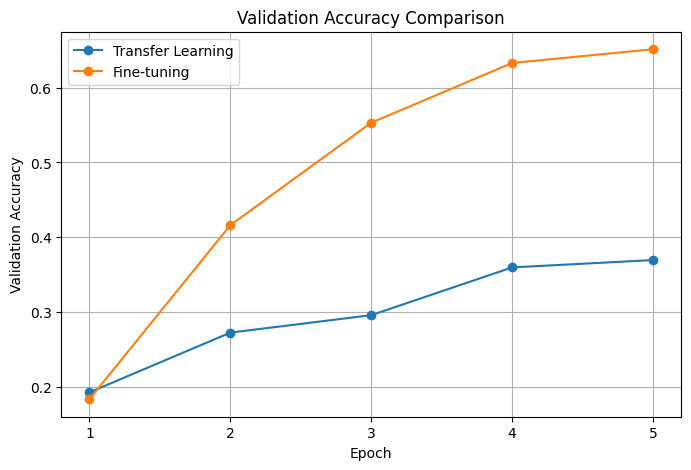

In [20]:
import matplotlib.pyplot as plt

epochs = range(1, 6)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["val_acc"],
    marker="o",
    label="Transfer Learning"
)

plt.plot(
    epochs,
    history_ft["val_acc"],
    marker="o",
    label="Fine-tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()

In [22]:
plt.savefig(
    "/content/val_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

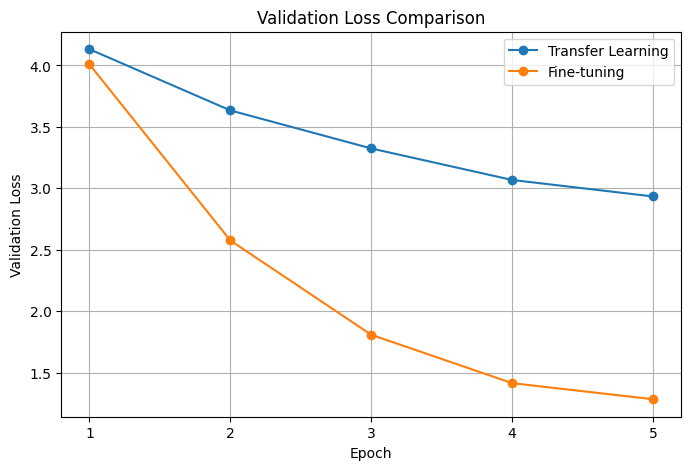

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Transfer Learning"
)

plt.plot(
    epochs,
    history_ft["val_loss"],
    marker="o",
    label="Fine-tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()

In [23]:
plt.savefig(
    "/content/val_loss_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [25]:
import os

RESULT_DIR = "/content/drive/MyDrive/stanford_cars_results"
os.makedirs(RESULT_DIR, exist_ok=True)

print("저장 경로:", RESULT_DIR)

저장 경로: /content/drive/MyDrive/stanford_cars_results


In [26]:
torch.save(
    model_ft.state_dict(),
    f"{RESULT_DIR}/resnet50_finetuned_layer4.pth"
)

In [27]:
plt.savefig(
    f"{RESULT_DIR}/val_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [28]:
plt.savefig(
    f"{RESULT_DIR}/val_loss_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [29]:
torch.save(
    model.state_dict(),
    f"{RESULT_DIR}/resnet50_transfer_learning.pth"
)

In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

model_ft.eval()

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_ft(images)
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

val_accuracy = accuracy_score(all_labels, all_preds)

print("Validation Accuracy:", f"{val_accuracy:.4f}")
print("Validation Samples:", len(all_labels))

Validation Accuracy: 0.6513
Validation Samples: 1629


In [31]:
cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=np.arange(196)
)

print("Confusion Matrix Shape:", cm.shape)

Confusion Matrix Shape: (196, 196)


In [32]:
class_total = cm.sum(axis=1)
class_correct = np.diag(cm)
class_wrong = class_total - class_correct

error_rate = class_wrong / class_total

top_error_classes = np.argsort(error_rate)[::-1][:10]

print("오분류율이 높은 클래스 TOP 10")
print()

for idx in top_error_classes:
    print(
        f"{idx:3d} | "
        f"{class_names[idx]} | "
        f"정답: {class_correct[idx]}/{class_total[idx]} | "
        f"오분류율: {error_rate[idx]:.2%}"
    )

오분류율이 높은 클래스 TOP 10

135 | Hyundai Accent Sedan 2012 | 정답: 0/5 | 오분류율: 100.00%
 42 | Bentley Continental GT Coupe 2007 | 정답: 1/9 | 오분류율: 88.89%
 36 | BMW X3 SUV 2012 | 정답: 1/8 | 오분류율: 87.50%
182 | Suzuki SX4 Hatchback 2012 | 정답: 1/8 | 오분류율: 87.50%
133 | Hyundai Sonata Hybrid Sedan 2012 | 정답: 1/7 | 오분류율: 85.71%
 38 | Bentley Continental Supersports Conv. Convertible 2012 | 정답: 1/7 | 오분류율: 85.71%
 73 | Chevrolet Silverado 1500 Extended Cab 2012 | 정답: 2/9 | 오분류율: 77.78%
 19 | Audi S6 Sedan 2011 | 정답: 2/9 | 오분류율: 77.78%
 14 | Audi R8 Coupe 2012 | 정답: 2/9 | 오분류율: 77.78%
 13 | Audi TTS Coupe 2012 | 정답: 2/9 | 오분류율: 77.78%


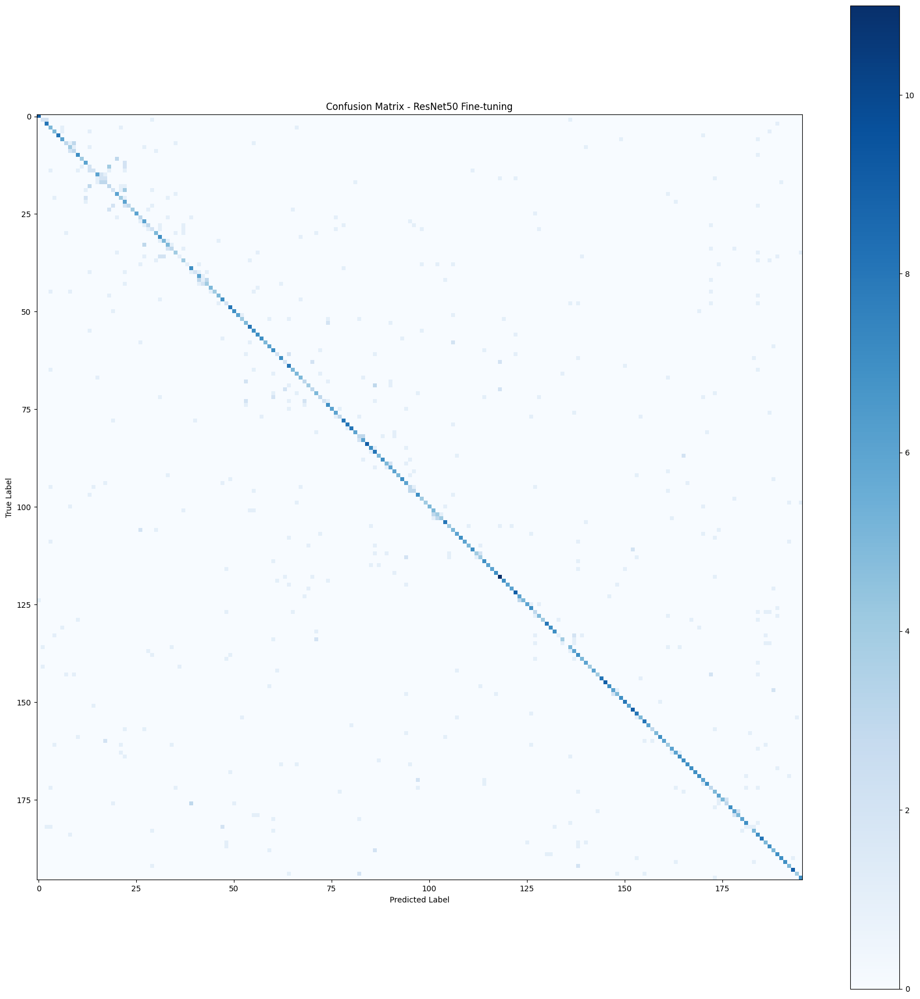

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 18))

plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - ResNet50 Fine-tuning")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/confusion_matrix_196x196.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
import pandas as pd

error_df = pd.DataFrame({
    "class_index": top_error_classes,
    "class_name": [class_names[i] for i in top_error_classes],
    "total_samples": [class_total[i] for i in top_error_classes],
    "correct": [class_correct[i] for i in top_error_classes],
    "wrong": [class_wrong[i] for i in top_error_classes],
    "error_rate": [error_rate[i] for i in top_error_classes]
})

error_df

,class_index,class_name,total_samples,correct,wrong,error_rate
0,135,Hyundai Accent Sedan 2012,5,0,5,1.000000
1,42,Bentley Continental GT Coupe 2007,9,1,8,0.888889
2,36,BMW X3 SUV 2012,8,1,7,0.875000
3,182,Suzuki SX4 Hatchback 2012,8,1,7,0.875000
4,133,Hyundai Sonata Hybrid Sedan 2012,7,1,6,0.857143
5,38,Bentley Continental Supersports Conv. Converti...,7,1,6,0.857143
6,73,Chevrolet Silverado 1500 Extended Cab 2012,9,2,7,0.777778
7,19,Audi S6 Sedan 2011,9,2,7,0.777778
8,14,Audi R8 Coupe 2012,9,2,7,0.777778
9,13,Audi TTS Coupe 2012,9,2,7,0.777778


In [35]:
error_df.to_csv(
    f"{RESULT_DIR}/top10_error_classes.csv",
    index=False,
    encoding="utf-8-sig"
)

print("오분류 TOP 10 저장 완료")

오분류 TOP 10 저장 완료


In [36]:
np.save(
    f"{RESULT_DIR}/confusion_matrix.npy",
    cm
)

print("Confusion Matrix 데이터 저장 완료")

Confusion Matrix 데이터 저장 완료


In [37]:
# True → Predicted 혼동 쌍 분석

confusion_pairs = []

for true_idx in range(196):
    for pred_idx in range(196):

        if true_idx == pred_idx:
            continue

        count = cm[true_idx, pred_idx]

        if count > 0:
            confusion_pairs.append({
                "true_class": true_idx,
                "true_name": class_names[true_idx],
                "pred_class": pred_idx,
                "pred_name": class_names[pred_idx],
                "count": int(count)
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs)

confusion_pairs_df = confusion_pairs_df.sort_values(
    "count",
    ascending=False
)

confusion_pairs_df.head(20)

,true_class,true_name,pred_class,pred_name,count
27,13,Audi TTS Coupe 2012,18,Audi TT Hatchback 2011,4
51,19,Audi S6 Sedan 2011,22,Audi S4 Sedan 2012,4
443,176,Rolls-Royce Phantom Sedan 2012,39,Bentley Arnage Sedan 2009,3
24,11,Audi RS 4 Convertible 2008,20,Audi S5 Convertible 2012,3
279,103,Ferrari 458 Italia Coupe 2012,102,Ferrari 458 Italia Convertible 2012,3
330,124,HUMMER H2 SUT Crew Cab 2009,123,HUMMER H3T Crew Cab 2010,3
231,82,Dodge Caliber Wagon 2012,83,Dodge Caliber Wagon 2007,3
95,33,BMW M3 Coupe 2012,27,BMW 1 Series Coupe 2012,3
46,18,Audi TT Hatchback 2011,13,Audi TTS Coupe 2012,3
262,96,Dodge Charger SRT-8 2009,95,Dodge Charger Sedan 2012,3


In [38]:
confusion_pairs_df.to_csv(
    f"{RESULT_DIR}/confusion_pairs.csv",
    index=False,
    encoding="utf-8-sig"
)

print("혼동 쌍 분석 결과 저장 완료")

혼동 쌍 분석 결과 저장 완료


In [39]:
from PIL import Image
import matplotlib.pyplot as plt

# 가장 많이 혼동한 pair
true_idx = 13
pred_idx = 18

# 해당 pair의 오분류 이미지 찾기
misclassified = []

for i, (true_label, pred_label) in enumerate(zip(all_labels, all_preds)):

    if true_label == true_idx and pred_label == pred_idx:
        image_path, _ = val_samples[i]
        misclassified.append(image_path)

print("오분류 이미지 수:", len(misclassified))
print("이미지 경로:")
for path in misclassified:
    print(path)

오분류 이미지 수: 4
이미지 경로:
/content/stanford_cars/cars_train/cars_train/00001.jpg
/content/stanford_cars/cars_train/cars_train/07423.jpg
/content/stanford_cars/cars_train/cars_train/03289.jpg
/content/stanford_cars/cars_train/cars_train/02766.jpg


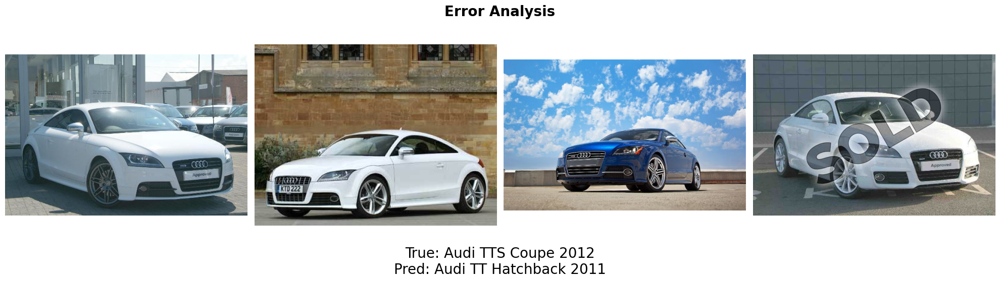

In [44]:
# =========================================================
# Error Analysis 시각화
# =========================================================

true_idx = 13
pred_idx = 18

misclassified = []

for i, (true_label, pred_label) in enumerate(zip(all_labels, all_preds)):

    if true_label == true_idx and pred_label == pred_idx:
        image_path, _ = val_samples[i]
        misclassified.append(image_path)


# Figure
fig, axes = plt.subplots(
    1,
    len(misclassified),
    figsize=(20, 6)
)

if len(misclassified) == 1:
    axes = [axes]


# 이미지 표시
for ax, image_path in zip(axes, misclassified):

    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)
    ax.axis("off")


# 제목
fig.suptitle(
    "Error Analysis",
    fontsize=20,
    fontweight="bold",
    y=0.93
)


# True / Pred
fig.text(
    0.5,
    0.08,
    f"True: {class_names[true_idx]}\n"
    f"Pred: {class_names[pred_idx]}",
    ha="center",
    va="center",
    fontsize=20
)


# 여백 최소화
plt.subplots_adjust(
    top=0.82,
    bottom=0.18,
    left=0.01,
    right=0.99,
    wspace=0.03
)


# 저장
plt.savefig(
    f"{RESULT_DIR}/error_analysis_audi_tts_to_tt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
plt.savefig(
    f"{RESULT_DIR}/error_analysis_audi_tts_to_tt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [46]:
# =========================================================
# Error Analysis
# Audi S6 Sedan 2011 → Audi S4 Sedan 2012
# =========================================================

true_idx = 19
pred_idx = 22

misclassified = []

for i, (true_label, pred_label) in enumerate(zip(all_labels, all_preds)):

    if true_label == true_idx and pred_label == pred_idx:
        image_path, _ = val_samples[i]
        misclassified.append(image_path)

print("오분류 이미지 수:", len(misclassified))

오분류 이미지 수: 4


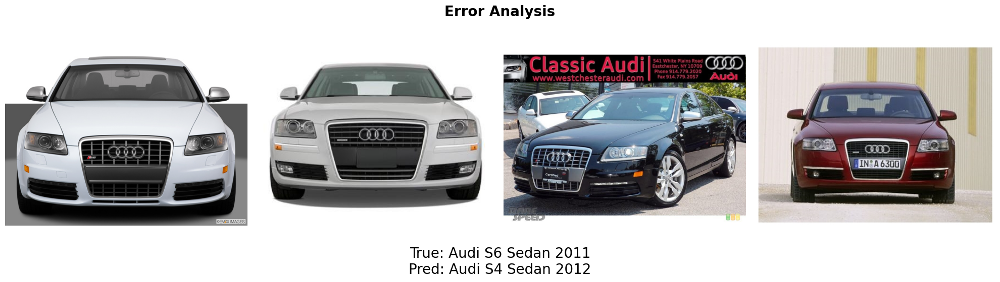

In [47]:
fig, axes = plt.subplots(
    1,
    len(misclassified),
    figsize=(20, 6)
)

if len(misclassified) == 1:
    axes = [axes]

for ax, image_path in zip(axes, misclassified):

    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)
    ax.axis("off")


fig.suptitle(
    "Error Analysis",
    fontsize=20,
    fontweight="bold",
    y=0.93
)

fig.text(
    0.5,
    0.08,
    f"True: {class_names[true_idx]}\n"
    f"Pred: {class_names[pred_idx]}",
    ha="center",
    va="center",
    fontsize=20
)

plt.subplots_adjust(
    top=0.82,
    bottom=0.18,
    left=0.01,
    right=0.99,
    wspace=0.03
)

plt.savefig(
    f"{RESULT_DIR}/error_analysis_audi_s6_to_s4.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
# =========================================================
# Error Analysis
# Rolls-Royce Phantom Sedan 2012 → Bentley Arnage Sedan 2009
# =========================================================

true_idx = 176
pred_idx = 39

misclassified = []

for i, (true_label, pred_label) in enumerate(zip(all_labels, all_preds)):

    if true_label == true_idx and pred_label == pred_idx:
        image_path, _ = val_samples[i]
        misclassified.append(image_path)

print("오분류 이미지 수:", len(misclassified))

오분류 이미지 수: 3


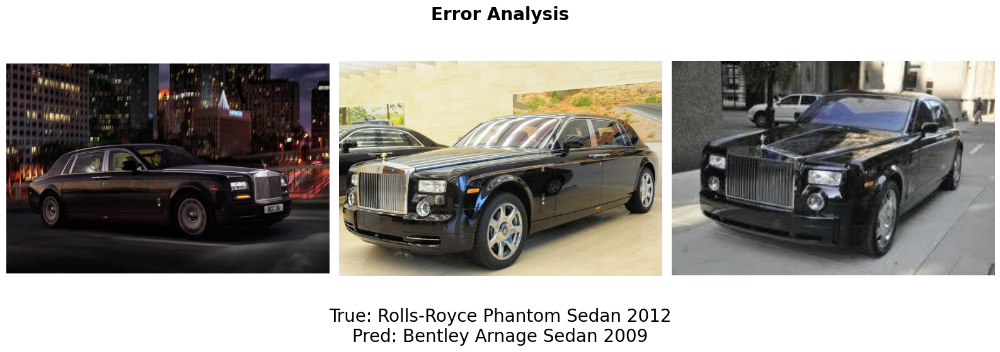

In [49]:
fig, axes = plt.subplots(
    1,
    len(misclassified),
    figsize=(16, 6)
)

if len(misclassified) == 1:
    axes = [axes]

for ax, image_path in zip(axes, misclassified):

    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)
    ax.axis("off")


fig.suptitle(
    "Error Analysis",
    fontsize=20,
    fontweight="bold",
    y=0.93
)

fig.text(
    0.5,
    0.08,
    f"True: {class_names[true_idx]}\n"
    f"Pred: {class_names[pred_idx]}",
    ha="center",
    va="center",
    fontsize=20
)

plt.subplots_adjust(
    top=0.82,
    bottom=0.18,
    left=0.01,
    right=0.99,
    wspace=0.03
)

plt.savefig(
    f"{RESULT_DIR}/error_analysis_phantom_to_arnage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

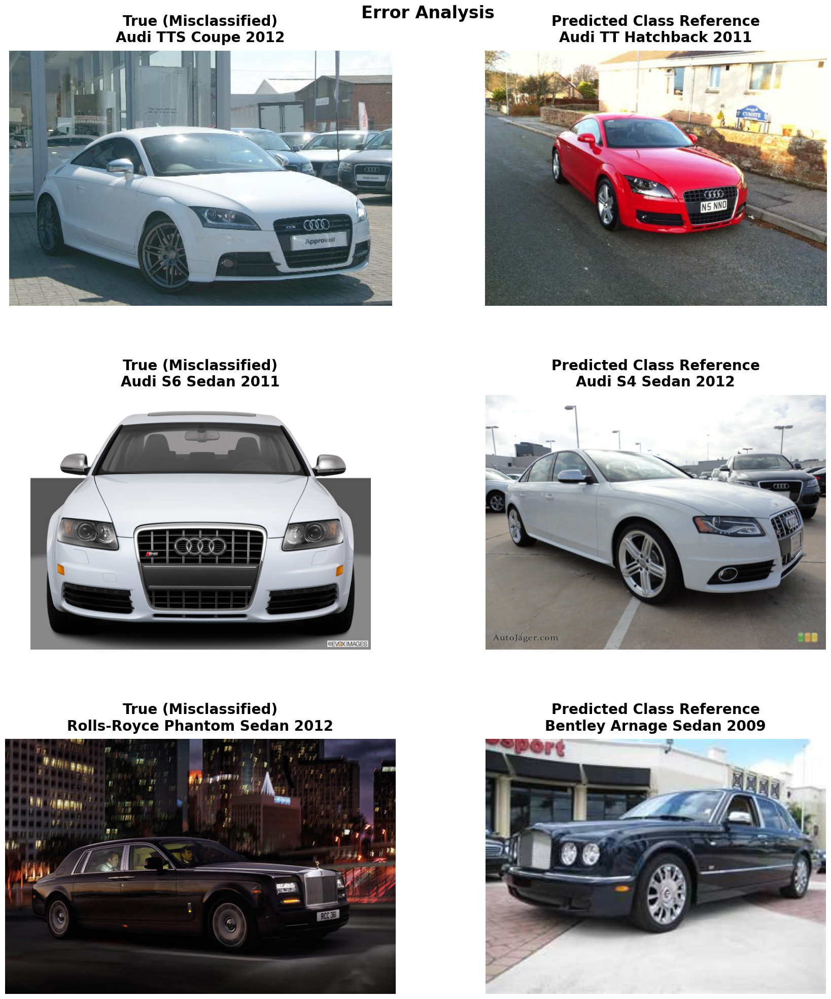

In [51]:
import matplotlib.pyplot as plt
from PIL import Image

# ============================================
# Error Analysis: 3개 혼동 사례 비교
# ============================================

cases = [
    (13, 18),    # Audi TTS Coupe 2012 → Audi TT Hatchback 2011
    (19, 22),    # Audi S6 Sedan 2011 → Audi S4 Sedan 2012
    (176, 39),   # Rolls-Royce Phantom Sedan 2012 → Bentley Arnage Sedan 2009
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(18, 20)
)

for row, (true_idx, pred_idx) in enumerate(cases):

    # ----------------------------------------
    # 1. 실제 오분류 이미지 찾기
    # ----------------------------------------
    misclassified_idx = next(
        i for i, (true, pred) in enumerate(zip(all_labels, all_preds))
        if true == true_idx and pred == pred_idx
    )

    misclassified_path = val_samples[misclassified_idx][0]

    # ----------------------------------------
    # 2. 예측 클래스의 실제 이미지 찾기
    #    → 해당 클래스를 올바르게 예측한 이미지 우선
    # ----------------------------------------
    reference_idx = next(
        i for i, (true, pred) in enumerate(zip(all_labels, all_preds))
        if true == pred_idx and pred == pred_idx
    )

    reference_path = val_samples[reference_idx][0]

    # 이미지 불러오기
    true_image = Image.open(misclassified_path).convert("RGB")
    pred_image = Image.open(reference_path).convert("RGB")

    # ----------------------------------------
    # 왼쪽: 실제 오분류 이미지
    # ----------------------------------------
    axes[row, 0].imshow(true_image)
    axes[row, 0].axis("off")
    axes[row, 0].set_title(
        f"True (Misclassified)\n{class_names[true_idx]}",
        fontsize=20,
        fontweight="bold",
        pad=12
    )

    # ----------------------------------------
    # 오른쪽: 예측 클래스의 실제 이미지
    # ----------------------------------------
    axes[row, 1].imshow(pred_image)
    axes[row, 1].axis("off")
    axes[row, 1].set_title(
        f"Predicted Class Reference\n{class_names[pred_idx]}",
        fontsize=20,
        fontweight="bold",
        pad=12
    )


# 전체 제목
fig.suptitle(
    "Error Analysis",
    fontsize=24,
    fontweight="bold",
    y=0.995
)

plt.subplots_adjust(
    top=0.95,
    bottom=0.02,
    left=0.02,
    right=0.98,
    hspace=0.35,
    wspace=0.08
)

# 저장
save_path = f"{RESULT_DIR}/error_analysis_3cases_comparison.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
import scipy.io as sio
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np
import os

# 경로
TRAIN_ANNO = "/content/stanford_cars/car_devkit/devkit/cars_train_annos.mat"
TRAIN_DIR = "/content/stanford_cars/cars_train/cars_train"

# annotation 불러오기
mat = sio.loadmat(TRAIN_ANNO)

annotations = mat["annotations"][0]

# filename -> bbox / class 매핑
bbox_dict = {}

for ann in annotations:
    x1 = int(ann[0].item())
    y1 = int(ann[1].item())
    x2 = int(ann[2].item())
    y2 = int(ann[3].item())
    cls = int(ann[4].item()) - 1
    fname = ann[5][0]

    bbox_dict[fname] = {
        "bbox": (x1, y1, x2, y2),
        "label": cls
    }

print("BBox annotations:", len(bbox_dict))

BBox annotations: 8144


In [53]:
def add_bbox_info(samples):
    new_samples = []

    for image_path, label in samples:
        fname = os.path.basename(image_path)

        if fname not in bbox_dict:
            continue

        bbox = bbox_dict[fname]["bbox"]

        new_samples.append(
            (image_path, label, bbox)
        )

    return new_samples


train_bbox_samples = add_bbox_info(train_samples)
val_bbox_samples = add_bbox_info(val_samples)

print("Train:", len(train_bbox_samples))
print("Validation:", len(val_bbox_samples))

Train: 6515
Validation: 1629


In [54]:
class StanfordCarsBBoxDataset(Dataset):

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        image_path, label, bbox = self.samples[idx]

        image = Image.open(image_path).convert("RGB")

        # bbox crop
        x1, y1, x2, y2 = bbox
        image = image.crop((x1, y1, x2, y2))

        if self.transform:
            image = self.transform(image)

        return image, label

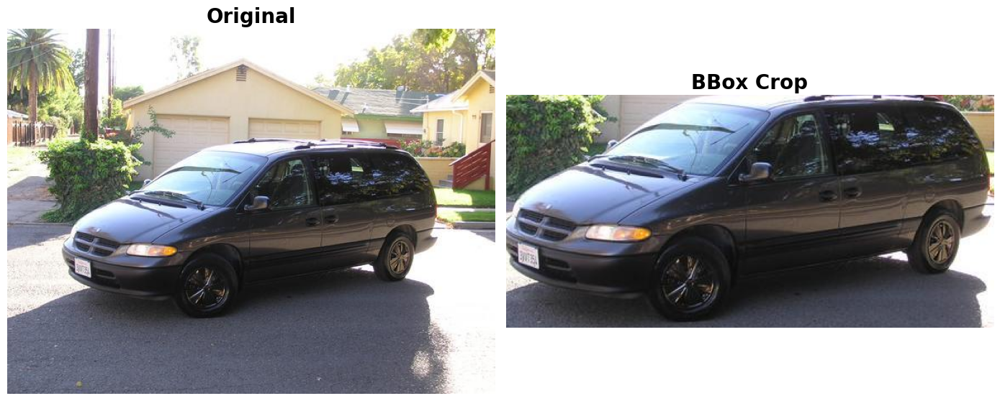

In [57]:
import matplotlib.pyplot as plt
from PIL import Image

# 확인할 샘플
image_path, label = train_samples[0]

# 원본
original = Image.open(image_path).convert("RGB")

# BBox
fname = os.path.basename(image_path)
x1, y1, x2, y2 = bbox_dict[fname]["bbox"]

# Crop
cropped = original.crop((x1, y1, x2, y2))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(original)
axes[0].axis("off")
axes[0].set_title("Original", fontsize=20, fontweight="bold")

axes[1].imshow(cropped)
axes[1].axis("off")
axes[1].set_title("BBox Crop", fontsize=20, fontweight="bold")

plt.tight_layout()
plt.show()

In [58]:
train_bbox_dataset = StanfordCarsBBoxDataset(
    train_bbox_samples,
    transform=train_transform
)

val_bbox_dataset = StanfordCarsBBoxDataset(
    val_bbox_samples,
    transform=val_transform
)

train_bbox_loader = DataLoader(
    train_bbox_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

val_bbox_loader = DataLoader(
    val_bbox_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

print("BBox Crop DataLoader ready")

BBox Crop DataLoader ready


In [59]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn
import torch.optim as optim

# ImageNet pretrained ResNet50 새로 생성
model_bbox = resnet50(weights=ResNet50_Weights.DEFAULT)

# FC 수정
model_bbox.fc = nn.Linear(2048, 196)

# Backbone 전체 freeze
for param in model_bbox.parameters():
    param.requires_grad = False

# Layer4 + FC만 학습
for param in model_bbox.layer4.parameters():
    param.requires_grad = True

for param in model_bbox.fc.parameters():
    param.requires_grad = True

# GPU
model_bbox = model_bbox.to(device)

# Loss
criterion_bbox = nn.CrossEntropyLoss()

# Optimizer
optimizer_bbox = optim.AdamW(
    filter(lambda p: p.requires_grad, model_bbox.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

# 학습 가능한 파라미터 확인
trainable_params = sum(
    p.numel() for p in model_bbox.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel() for p in model_bbox.parameters()
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 23,909,636
Trainable parameters: 15,366,340


In [60]:
num_epochs = 5

bbox_train_losses = []
bbox_train_accs = []
bbox_val_losses = []
bbox_val_accs = []

for epoch in range(num_epochs):

    # =========================
    # Train
    # =========================
    model_bbox.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_bbox_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_bbox.zero_grad()

        outputs = model_bbox(images)
        loss = criterion_bbox(outputs, labels)

        loss.backward()
        optimizer_bbox.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # =========================
    # Validation
    # =========================
    model_bbox.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_bbox_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_bbox(images)
            loss = criterion_bbox(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    # 기록
    bbox_train_losses.append(train_loss)
    bbox_train_accs.append(train_acc)
    bbox_val_losses.append(val_loss)
    bbox_val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/5] Train Loss: 4.9492, Train Acc: 0.0534, Val Loss: 4.3311, Val Acc: 0.1584
Epoch [2/5] Train Loss: 3.2899, Train Acc: 0.3483, Val Loss: 3.0125, Val Acc: 0.3524
Epoch [3/5] Train Loss: 1.9483, Train Acc: 0.6267, Val Loss: 2.3018, Val Acc: 0.4672
Epoch [4/5] Train Loss: 1.1502, Train Acc: 0.7862, Val Loss: 1.9278, Val Acc: 0.5261
Epoch [5/5] Train Loss: 0.6776, Train Acc: 0.8863, Val Loss: 1.7110, Val Acc: 0.5678


최종 모델용으로 최대 20 Epoch + Early Stopping + Best Checkpoint 저장.

기존 model_ft나 model_bbox는 건드리지 않고 ImageNet pretrained에서 새로 시작한다.

In [61]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights

# ==========================================
# 1. Final Model
# ==========================================

model_final = resnet50(weights=ResNet50_Weights.DEFAULT)

# FC: 1000 → 196
model_final.fc = nn.Linear(2048, 196)

# 전체 Freeze
for param in model_final.parameters():
    param.requires_grad = False

# Layer4 + FC Fine-tuning
for param in model_final.layer4.parameters():
    param.requires_grad = True

for param in model_final.fc.parameters():
    param.requires_grad = True

model_final = model_final.to(device)

# ==========================================
# 2. Loss / Optimizer
# ==========================================

criterion_final = nn.CrossEntropyLoss()

optimizer_final = optim.AdamW(
    filter(lambda p: p.requires_grad, model_final.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

# ==========================================
# 3. Early Stopping 설정
# ==========================================

max_epochs = 20
patience = 3

best_val_loss = float("inf")
best_val_acc = 0.0
best_epoch = 0
patience_counter = 0

best_model_state = None

# 기록
final_train_losses = []
final_train_accs = []
final_val_losses = []
final_val_accs = []

# ==========================================
# 4. Training
# ==========================================

for epoch in range(max_epochs):

    # --------------------------------------
    # Train
    # --------------------------------------
    model_final.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_final.zero_grad()

        outputs = model_final(images)
        loss = criterion_final(outputs, labels)

        loss.backward()
        optimizer_final.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # --------------------------------------
    # Validation
    # --------------------------------------
    model_final.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_final(images)
            loss = criterion_final(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    # --------------------------------------
    # 기록
    # --------------------------------------

    final_train_losses.append(train_loss)
    final_train_accs.append(train_acc)
    final_val_losses.append(val_loss)
    final_val_accs.append(val_acc)

    # --------------------------------------
    # Best Model
    # Validation Loss 기준 Early Stopping
    # --------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_val_acc = val_acc
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model_final.state_dict()
        )

        patience_counter = 0

        print(
            f"Epoch [{epoch+1}/{max_epochs}] "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_acc:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_acc:.4f} "
            f"← Best"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch+1}/{max_epochs}] "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_acc:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_acc:.4f} "
            f"(patience {patience_counter}/{patience})"
        )

    # --------------------------------------
    # Early Stopping
    # --------------------------------------

    if patience_counter >= patience:

        print()
        print(
            f"Early Stopping at Epoch {epoch+1}"
        )
        break


# ==========================================
# 5. Best Model 복원
# ==========================================

model_final.load_state_dict(best_model_state)

print()
print("=" * 50)
print("Final Training Complete")
print("=" * 50)
print(f"Best Epoch       : {best_epoch}")
print(f"Best Val Loss    : {best_val_loss:.4f}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")

Epoch [1/20] Train Loss: 4.8429, Train Acc: 0.0628, Val Loss: 3.9105, Val Acc: 0.1829 ← Best
Epoch [2/20] Train Loss: 3.0426, Train Acc: 0.3733, Val Loss: 2.4937, Val Acc: 0.4217 ← Best
Epoch [3/20] Train Loss: 1.7489, Train Acc: 0.6436, Val Loss: 1.8183, Val Acc: 0.5648 ← Best
Epoch [4/20] Train Loss: 1.0424, Train Acc: 0.7928, Val Loss: 1.4321, Val Acc: 0.6286 ← Best
Epoch [5/20] Train Loss: 0.6352, Train Acc: 0.8878, Val Loss: 1.2362, Val Acc: 0.6814 ← Best
Epoch [6/20] Train Loss: 0.4047, Train Acc: 0.9340, Val Loss: 1.1701, Val Acc: 0.6900 ← Best
Epoch [7/20] Train Loss: 0.2677, Train Acc: 0.9612, Val Loss: 1.0697, Val Acc: 0.7090 ← Best
Epoch [8/20] Train Loss: 0.1859, Train Acc: 0.9739, Val Loss: 0.9961, Val Acc: 0.7268 ← Best
Epoch [9/20] Train Loss: 0.1287, Train Acc: 0.9839, Val Loss: 0.9798, Val Acc: 0.7342 ← Best
Epoch [10/20] Train Loss: 0.1010, Train Acc: 0.9859, Val Loss: 0.9858, Val Acc: 0.7250 (patience 1/3)
Epoch [11/20] Train Loss: 0.0790, Train Acc: 0.9922, Val Loss

In [62]:
# ==========================================
# Final Training v2
# Seed 고정 + Early Stopping + Best Accuracy 저장
# ==========================================

import os
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.models import resnet50, ResNet50_Weights

# ------------------------------------------
# 1. Seed 고정
# ------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed: {SEED}")


# ------------------------------------------
# 2. 새로운 Final Model 생성
# ------------------------------------------

model_final_v2 = resnet50(
    weights=ResNet50_Weights.DEFAULT
)

# FC: 1000 → 196
model_final_v2.fc = nn.Linear(
    2048,
    196
)

# 전체 Freeze
for param in model_final_v2.parameters():
    param.requires_grad = False

# Layer4 + FC만 Fine-tuning
for param in model_final_v2.layer4.parameters():
    param.requires_grad = True

for param in model_final_v2.fc.parameters():
    param.requires_grad = True

model_final_v2 = model_final_v2.to(device)


# ------------------------------------------
# 3. Loss / Optimizer
# ------------------------------------------

criterion_final_v2 = nn.CrossEntropyLoss()

optimizer_final_v2 = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model_final_v2.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4
)


# ------------------------------------------
# 4. 학습 설정
# ------------------------------------------

max_epochs = 20
patience = 3

best_val_loss = float("inf")
best_val_acc = 0.0

best_loss_epoch = 0
best_acc_epoch = 0

best_loss_state = None
best_acc_state = None

patience_counter = 0


# ------------------------------------------
# 5. 기록
# ------------------------------------------

final_v2_train_losses = []
final_v2_train_accs = []

final_v2_val_losses = []
final_v2_val_accs = []


# ------------------------------------------
# 6. Training
# ------------------------------------------

for epoch in range(max_epochs):

    # ======================================
    # Train
    # ======================================

    model_final_v2.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_final_v2.zero_grad()

        outputs = model_final_v2(images)

        loss = criterion_final_v2(
            outputs,
            labels
        )

        loss.backward()

        optimizer_final_v2.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        preds = outputs.argmax(dim=1)

        correct += (
            (preds == labels).sum().item()
        )

        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total


    # ======================================
    # Validation
    # ======================================

    model_final_v2.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_final_v2(images)

            loss = criterion_final_v2(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            preds = outputs.argmax(dim=1)

            correct += (
                (preds == labels).sum().item()
            )

            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total


    # ======================================
    # 기록
    # ======================================

    final_v2_train_losses.append(train_loss)
    final_v2_train_accs.append(train_acc)

    final_v2_val_losses.append(val_loss)
    final_v2_val_accs.append(val_acc)


    # ======================================
    # Best Validation Accuracy 저장
    # ======================================

    if val_acc > best_val_acc:

        best_val_acc = val_acc
        best_acc_epoch = epoch + 1

        best_acc_state = copy.deepcopy(
            model_final_v2.state_dict()
        )

        acc_message = " ← Best Accuracy"

    else:

        acc_message = ""


    # ======================================
    # Early Stopping
    # Validation Loss 기준
    # ======================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_loss_epoch = epoch + 1

        best_loss_state = copy.deepcopy(
            model_final_v2.state_dict()
        )

        patience_counter = 0

    else:

        patience_counter += 1


    # ======================================
    # 출력
    # ======================================

    print(
        f"Epoch [{epoch+1}/{max_epochs}] "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_acc:.4f}"
        f"{acc_message} "
        f"(patience {patience_counter}/{patience})"
    )


    # ======================================
    # Early Stopping
    # ======================================

    if patience_counter >= patience:

        print()
        print(
            f"Early Stopping at Epoch {epoch+1}"
        )

        break


# ------------------------------------------
# 7. Best Accuracy 모델 복원
# ------------------------------------------

model_final_v2.load_state_dict(
    best_acc_state
)


# ------------------------------------------
# 8. 결과 출력
# ------------------------------------------

print()
print("=" * 55)
print("Final Training v2 Complete")
print("=" * 55)

print(
    f"Best Accuracy Epoch : {best_acc_epoch}"
)

print(
    f"Best Val Accuracy   : {best_val_acc:.4f} "
    f"({best_val_acc * 100:.2f}%)"
)

print(
    f"Best Loss Epoch     : {best_loss_epoch}"
)

print(
    f"Best Val Loss       : {best_val_loss:.4f}"
)

Seed: 42
Epoch [1/20] Train Loss: 4.8633, Train Acc: 0.0583, Val Loss: 3.9978, Val Acc: 0.1645 ← Best Accuracy (patience 0/3)
Epoch [2/20] Train Loss: 3.1637, Train Acc: 0.3408, Val Loss: 2.6147, Val Acc: 0.4082 ← Best Accuracy (patience 0/3)
Epoch [3/20] Train Loss: 1.8432, Train Acc: 0.6235, Val Loss: 1.8166, Val Acc: 0.5672 ← Best Accuracy (patience 0/3)
Epoch [4/20] Train Loss: 1.1102, Train Acc: 0.7850, Val Loss: 1.4614, Val Acc: 0.6341 ← Best Accuracy (patience 0/3)
Epoch [5/20] Train Loss: 0.6872, Train Acc: 0.8740, Val Loss: 1.2462, Val Acc: 0.6753 ← Best Accuracy (patience 0/3)
Epoch [6/20] Train Loss: 0.4363, Train Acc: 0.9249, Val Loss: 1.1167, Val Acc: 0.6967 ← Best Accuracy (patience 0/3)
Epoch [7/20] Train Loss: 0.2890, Train Acc: 0.9530, Val Loss: 1.0874, Val Acc: 0.6955 (patience 0/3)
Epoch [8/20] Train Loss: 0.1969, Train Acc: 0.9721, Val Loss: 1.0374, Val Acc: 0.7145 ← Best Accuracy (patience 0/3)
Epoch [9/20] Train Loss: 0.1349, Train Acc: 0.9819, Val Loss: 1.0179, V

In [63]:
# ==========================================
# Final V2 결과 저장
# 모델 + 학습 설정 + 결과 기록
# ==========================================

import os
import torch
import pandas as pd

# 결과 폴더
os.makedirs(RESULT_DIR, exist_ok=True)


# ==========================================
# 1. Best Accuracy 모델 + 설정 저장
# ==========================================

checkpoint = {
    # 모델
    "model_state_dict": model_final_v2.state_dict(),

    # 모델 정보
    "model_name": "ResNet50",
    "pretrained": "ImageNet",
    "num_classes": 196,
    "fine_tuning": "layer4 + fc",

    # 학습 설정
    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "batch_size": 32,

    # Early Stopping
    "max_epochs": 20,
    "early_stopping_patience": 3,

    # 재현성
    "seed": 42,

    # 최종 결과
    "best_acc_epoch": best_acc_epoch,
    "best_val_accuracy": best_val_acc,
    "best_loss_epoch": best_loss_epoch,
    "best_val_loss": best_val_loss,

    # 클래스 이름
    "class_names": class_names
}


checkpoint_path = (
    f"{RESULT_DIR}/resnet50_final_v2_checkpoint.pth"
)

torch.save(
    checkpoint,
    checkpoint_path
)


# ==========================================
# 2. 학습 기록 저장
# ==========================================

history_v2 = pd.DataFrame({
    "epoch": range(
        1,
        len(final_v2_train_losses) + 1
    ),
    "train_loss": final_v2_train_losses,
    "train_accuracy": final_v2_train_accs,
    "val_loss": final_v2_val_losses,
    "val_accuracy": final_v2_val_accs
})

history_path = (
    f"{RESULT_DIR}/final_v2_training_history.csv"
)

history_v2.to_csv(
    history_path,
    index=False
)


# ==========================================
# 3. 최종 결과 출력
# ==========================================

print("=" * 55)
print("Final V2 Results Saved")
print("=" * 55)

print(f"Best Epoch        : {best_acc_epoch}")
print(
    f"Best Val Accuracy : "
    f"{best_val_acc:.4f} "
    f"({best_val_acc * 100:.2f}%)"
)

print(f"Best Loss Epoch   : {best_loss_epoch}")
print(
    f"Best Val Loss     : "
    f"{best_val_loss:.4f}"
)

print()
print("Saved:")
print(f"- {checkpoint_path}")
print(f"- {history_path}")

Final V2 Results Saved
Best Epoch        : 14
Best Val Accuracy : 0.7330 (73.30%)
Best Loss Epoch   : 14
Best Val Loss     : 0.9866

Saved:
- /content/drive/MyDrive/stanford_cars_results/resnet50_final_v2_checkpoint.pth
- /content/drive/MyDrive/stanford_cars_results/final_v2_training_history.csv


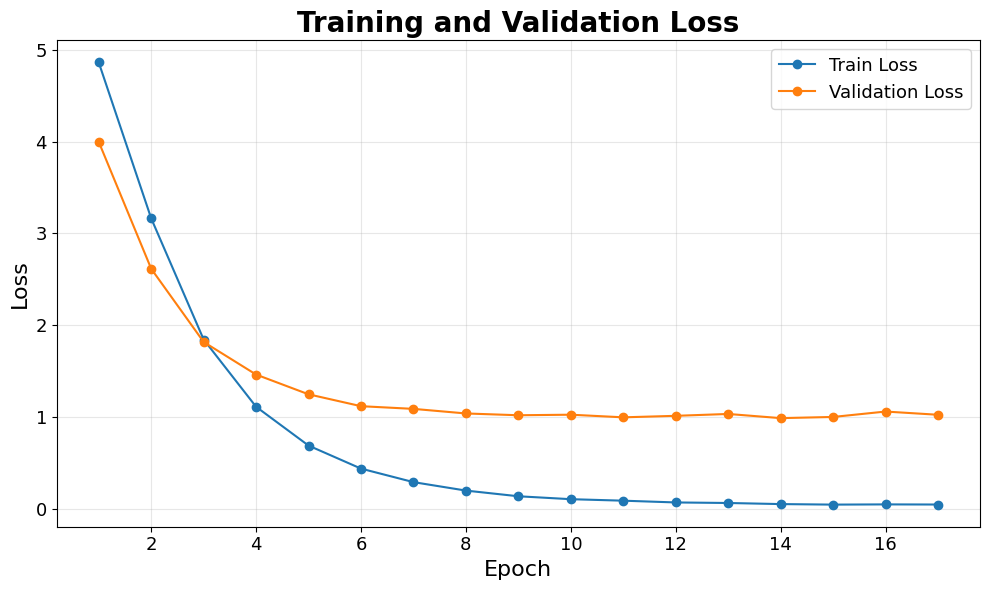

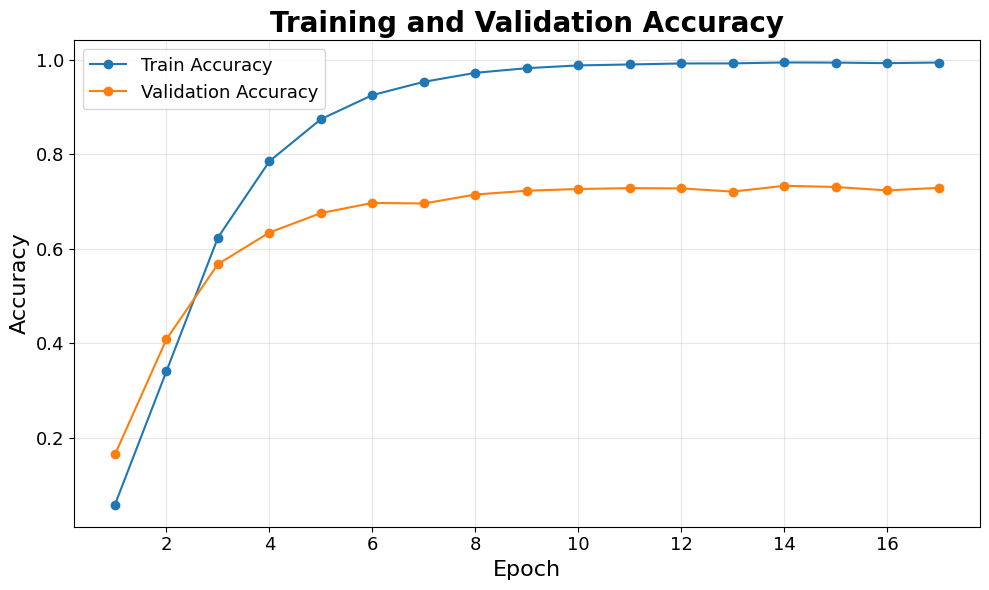

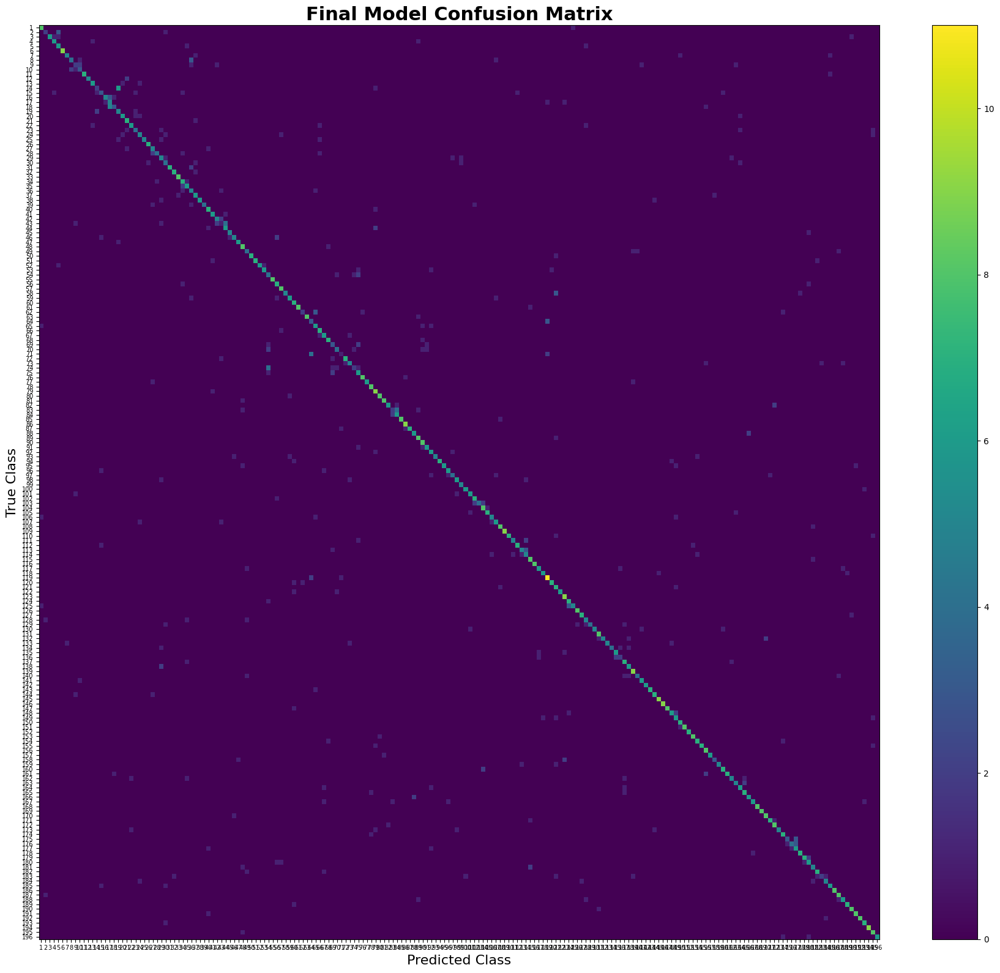


FINAL MODEL EVALUATION
Accuracy        : 0.7330 (73.30%)
Macro Precision : 0.7574
Macro Recall    : 0.7312
Macro F1        : 0.7302
Weighted F1     : 0.7320

Saved files:
- /content/drive/MyDrive/stanford_cars_results/resnet50_final_v2_best_acc.pth
- /content/drive/MyDrive/stanford_cars_results/final_v2_training_history.csv
- /content/drive/MyDrive/stanford_cars_results/final_v2_loss_curve.png
- /content/drive/MyDrive/stanford_cars_results/final_v2_accuracy_curve.png
- /content/drive/MyDrive/stanford_cars_results/final_v2_metrics.csv
- /content/drive/MyDrive/stanford_cars_results/final_v2_classification_report.csv
- /content/drive/MyDrive/stanford_cars_results/final_v2_confusion_matrix.png
- /content/drive/MyDrive/stanford_cars_results/final_v2_summary.txt


In [64]:
# ==========================================
# Final V2 - Complete Evaluation & Saving
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 결과 폴더
os.makedirs(RESULT_DIR, exist_ok=True)


# ==========================================
# 1. Best Accuracy 모델 저장
# ==========================================

model_path = f"{RESULT_DIR}/resnet50_final_v2_best_acc.pth"

torch.save(
    model_final_v2.state_dict(),
    model_path
)


# ==========================================
# 2. Training History 저장
# ==========================================

history_v2 = pd.DataFrame({
    "epoch": range(1, len(final_v2_train_losses) + 1),
    "train_loss": final_v2_train_losses,
    "train_accuracy": final_v2_train_accs,
    "val_loss": final_v2_val_losses,
    "val_accuracy": final_v2_val_accs
})

history_path = f"{RESULT_DIR}/final_v2_training_history.csv"

history_v2.to_csv(
    history_path,
    index=False
)


# ==========================================
# 3. Loss Curve
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_v2["epoch"],
    history_v2["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    history_v2["epoch"],
    history_v2["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.title("Training and Validation Loss", fontsize=20, fontweight="bold")

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=13)
plt.grid(alpha=0.3)

plt.tight_layout()

loss_path = f"{RESULT_DIR}/final_v2_loss_curve.png"

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 4. Accuracy Curve
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_v2["epoch"],
    history_v2["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    history_v2["epoch"],
    history_v2["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Accuracy", fontsize=16)
plt.title(
    "Training and Validation Accuracy",
    fontsize=20,
    fontweight="bold"
)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=13)
plt.grid(alpha=0.3)

plt.tight_layout()

accuracy_path = f"{RESULT_DIR}/final_v2_accuracy_curve.png"

plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 5. Validation Prediction
# ==========================================

model_final_v2.eval()

all_labels_v2 = []
all_preds_v2 = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model_final_v2(images)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        all_labels_v2.extend(
            labels.numpy()
        )

        all_preds_v2.extend(
            preds.cpu().numpy()
        )


all_labels_v2 = np.array(all_labels_v2)
all_preds_v2 = np.array(all_preds_v2)


# ==========================================
# 6. 주요 평가 지표
# ==========================================

accuracy = accuracy_score(
    all_labels_v2,
    all_preds_v2
)

precision_macro = precision_score(
    all_labels_v2,
    all_preds_v2,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    all_labels_v2,
    all_preds_v2,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    all_labels_v2,
    all_preds_v2,
    average="macro",
    zero_division=0
)

f1_weighted = f1_score(
    all_labels_v2,
    all_preds_v2,
    average="weighted",
    zero_division=0
)


# ==========================================
# 7. Metrics CSV
# ==========================================

metrics_v2 = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "Best Epoch",
        "Best Validation Loss"
    ],
    "Value": [
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        f1_weighted,
        best_acc_epoch,
        best_loss_epoch
    ]
})

metrics_path = f"{RESULT_DIR}/final_v2_metrics.csv"

metrics_v2.to_csv(
    metrics_path,
    index=False
)


# ==========================================
# 8. Classification Report
# ==========================================

report = classification_report(
    all_labels_v2,
    all_preds_v2,
    labels=np.arange(196),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_path = (
    f"{RESULT_DIR}/final_v2_classification_report.csv"
)

report_df.to_csv(
    report_path
)


# ==========================================
# 9. Confusion Matrix
# ==========================================

cm_v2 = confusion_matrix(
    all_labels_v2,
    all_preds_v2,
    labels=np.arange(196)
)

np.save(
    f"{RESULT_DIR}/final_v2_confusion_matrix.npy",
    cm_v2
)


# ==========================================
# 10. Confusion Matrix Visualization
# ==========================================

plt.figure(figsize=(18, 16))

plt.imshow(
    cm_v2,
    interpolation="nearest",
    aspect="auto"
)

plt.title(
    "Final Model Confusion Matrix",
    fontsize=22,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Class",
    fontsize=16
)

plt.ylabel(
    "True Class",
    fontsize=16
)

plt.colorbar()

plt.xticks(
    np.arange(196),
    np.arange(1, 197),
    fontsize=7
)

plt.yticks(
    np.arange(196),
    np.arange(1, 197),
    fontsize=7
)

plt.tight_layout()

cm_path = f"{RESULT_DIR}/final_v2_confusion_matrix.png"

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 11. Summary TXT
# ==========================================

summary_path = f"{RESULT_DIR}/final_v2_summary.txt"

with open(summary_path, "w", encoding="utf-8") as f:

    f.write("Stanford Cars - Final ResNet50 Model\n")
    f.write("=" * 50 + "\n\n")

    f.write("Model\n")
    f.write("-" * 50 + "\n")
    f.write("Backbone: ResNet50\n")
    f.write("Pretrained: ImageNet\n")
    f.write("Fine-tuning: Layer4 + FC\n")
    f.write("Classes: 196\n")
    f.write("Optimizer: AdamW\n")
    f.write("Learning Rate: 1e-4\n")
    f.write("Weight Decay: 1e-4\n")
    f.write("Maximum Epochs: 20\n")
    f.write("Early Stopping Patience: 3\n\n")

    f.write("Training Result\n")
    f.write("-" * 50 + "\n")
    f.write(f"Best Accuracy Epoch: {best_acc_epoch}\n")
    f.write(f"Best Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    f.write(f"Best Loss Epoch: {best_loss_epoch}\n")
    f.write(f"Best Validation Loss: {best_val_loss:.4f}\n\n")

    f.write("Evaluation Metrics\n")
    f.write("-" * 50 + "\n")
    f.write(
        f"Accuracy: {accuracy:.4f} "
        f"({accuracy*100:.2f}%)\n"
    )
    f.write(
        f"Macro Precision: {precision_macro:.4f}\n"
    )
    f.write(
        f"Macro Recall: {recall_macro:.4f}\n"
    )
    f.write(
        f"Macro F1: {f1_macro:.4f}\n"
    )
    f.write(
        f"Weighted F1: {f1_weighted:.4f}\n"
    )


# ==========================================
# 12. 결과 출력
# ==========================================

print()
print("=" * 60)
print("FINAL MODEL EVALUATION")
print("=" * 60)

print(f"Accuracy        : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Macro Precision : {precision_macro:.4f}")
print(f"Macro Recall    : {recall_macro:.4f}")
print(f"Macro F1        : {f1_macro:.4f}")
print(f"Weighted F1     : {f1_weighted:.4f}")

print()
print("Saved files:")
print(f"- {model_path}")
print(f"- {history_path}")
print(f"- {loss_path}")
print(f"- {accuracy_path}")
print(f"- {metrics_path}")
print(f"- {report_path}")
print(f"- {cm_path}")
print(f"- {summary_path}")

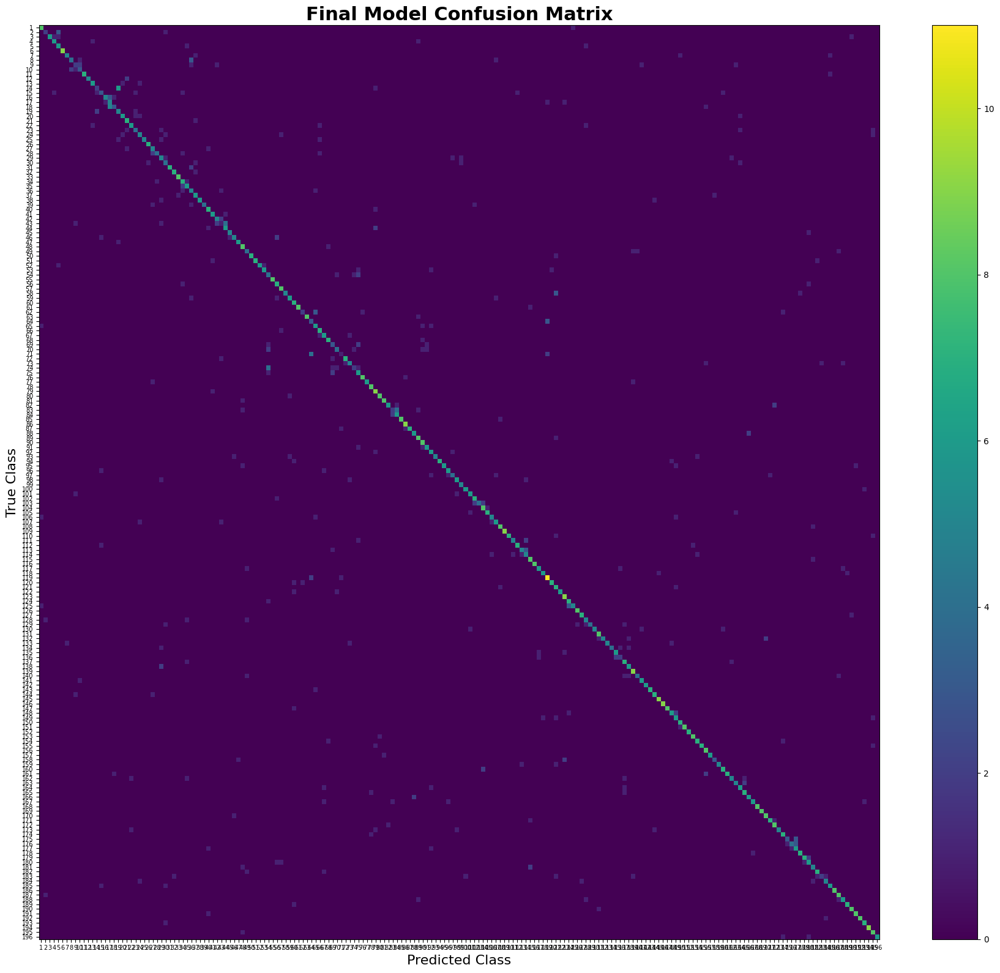

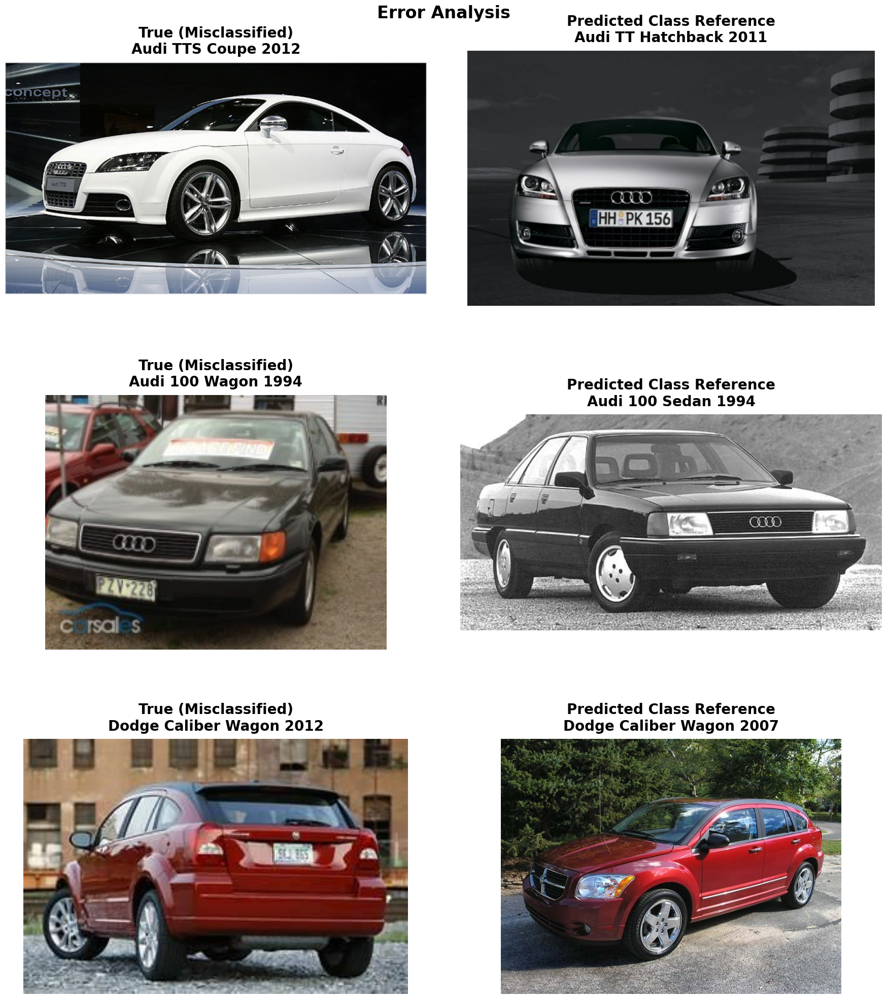

Final V2 Error Analysis Complete

Top Confusion Pairs
------------------------------------------------------------


,true_class,pred_class,count
0,Audi TTS Coupe 2012,Audi TT Hatchback 2011,6
1,Audi 100 Wagon 1994,Audi 100 Sedan 1994,5
2,Dodge Caliber Wagon 2012,Dodge Caliber Wagon 2007,4
3,Bentley Continental GT Coupe 2007,Bentley Continental Flying Spur Sedan 2007,4
4,Chevrolet Express Van 2007,Chevrolet Express Cargo Van 2007,4
5,Chevrolet Silverado 1500 Extended Cab 2012,Chevrolet Silverado 1500 Hybrid Crew Cab 2012,4
6,Aston Martin V8 Vantage Convertible 2012,BMW M6 Convertible 2010,3
7,Rolls-Royce Ghost Sedan 2012,Rolls-Royce Phantom Sedan 2012,3
8,Chevrolet Traverse SUV 2012,GMC Acadia SUV 2012,3
9,Ford F-150 Regular Cab 2012,Ford F-150 Regular Cab 2007,3



Selected Error Analysis Cases
------------------------------------------------------------


,case,true_class,pred_class,confusion_count
0,1,Audi TTS Coupe 2012,Audi TT Hatchback 2011,6
1,2,Audi 100 Wagon 1994,Audi 100 Sedan 1994,5
2,3,Dodge Caliber Wagon 2012,Dodge Caliber Wagon 2007,4



Saved:
- /content/drive/MyDrive/stanford_cars_results/final_v2_confusion_matrix.npy
- /content/drive/MyDrive/stanford_cars_results/final_v2_confusion_matrix.png
- /content/drive/MyDrive/stanford_cars_results/final_v2_top10_confusion_pairs.csv
- /content/drive/MyDrive/stanford_cars_results/final_v2_error_analysis_cases.csv
- /content/drive/MyDrive/stanford_cars_results/final_v2_error_analysis_3cases.png


In [69]:
# ==========================================
# Final V2 Error Analysis
# Confusion Matrix + Top Confusion Pairs
# + Representative 3 Cases
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import confusion_matrix


# ==========================================
# 0. 결과 폴더
# ==========================================

os.makedirs(RESULT_DIR, exist_ok=True)


# ==========================================
# 1. V2 Confusion Matrix
# ==========================================

cm_v2 = confusion_matrix(
    all_labels_v2,
    all_preds_v2,
    labels=np.arange(196)
)

# 저장
cm_npy_path = (
    f"{RESULT_DIR}/final_v2_confusion_matrix.npy"
)

np.save(
    cm_npy_path,
    cm_v2
)


# ==========================================
# 2. Confusion Matrix 시각화
# ==========================================

plt.figure(figsize=(18, 16))

plt.imshow(
    cm_v2,
    interpolation="nearest",
    aspect="auto"
)

plt.title(
    "Final Model Confusion Matrix",
    fontsize=22,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Class",
    fontsize=16
)

plt.ylabel(
    "True Class",
    fontsize=16
)

plt.colorbar()

plt.xticks(
    np.arange(196),
    np.arange(1, 197),
    fontsize=7
)

plt.yticks(
    np.arange(196),
    np.arange(1, 197),
    fontsize=7
)

plt.tight_layout()

cm_png_path = (
    f"{RESULT_DIR}/final_v2_confusion_matrix.png"
)

plt.savefig(
    cm_png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 3. 상위 Confusion Pair 추출
# ==========================================

confusion_pairs = []

for true_idx in range(196):

    for pred_idx in range(196):

        # 정답과 예측이 같은 경우 제외
        if true_idx == pred_idx:
            continue

        count = cm_v2[true_idx, pred_idx]

        if count > 0:

            confusion_pairs.append({
                "true_idx": true_idx,
                "pred_idx": pred_idx,
                "true_class": class_names[true_idx],
                "pred_class": class_names[pred_idx],
                "count": int(count)
            })


# 많이 혼동된 순서대로 정렬
confusion_pairs_df = pd.DataFrame(
    confusion_pairs
).sort_values(
    by="count",
    ascending=False
).reset_index(drop=True)


# Top 10 저장
top10_pairs = confusion_pairs_df.head(10)

top10_path = (
    f"{RESULT_DIR}/final_v2_top10_confusion_pairs.csv"
)

top10_pairs.to_csv(
    top10_path,
    index=False,
    encoding="utf-8-sig"
)


# ==========================================
# 4. 대표 Error Analysis 3개 선정
# ==========================================

# 상위 confusion pair 중에서
# 서로 다른 사례 3개 선택

selected_cases = []

used_pairs = set()

for _, row in confusion_pairs_df.iterrows():

    true_idx = int(row["true_idx"])
    pred_idx = int(row["pred_idx"])

    pair = (true_idx, pred_idx)

    if pair in used_pairs:
        continue

    selected_cases.append(
        (true_idx, pred_idx)
    )

    used_pairs.add(pair)

    if len(selected_cases) == 3:
        break


# ==========================================
# 5. 각 사례의 실제 이미지 찾기
# ==========================================

case_records = []

for case_num, (true_idx, pred_idx) in enumerate(
    selected_cases,
    start=1
):

    # --------------------------------------
    # 실제 오분류 이미지
    # --------------------------------------

    misclassified_indices = [
        i
        for i, (true, pred)
        in enumerate(zip(all_labels_v2, all_preds_v2))
        if true == true_idx and pred == pred_idx
    ]

    if len(misclassified_indices) == 0:
        continue

    misclassified_idx = misclassified_indices[-1]

    misclassified_path = (
        val_samples[misclassified_idx][0]
    )


    # --------------------------------------
    # Predicted 클래스의 실제 이미지
    # 모델이 정확하게 예측한 이미지 우선
    # --------------------------------------

    reference_indices = [
        i
        for i, (true, pred)
        in enumerate(zip(all_labels_v2, all_preds_v2))
        if true == pred_idx and pred == pred_idx
    ]


    # 정확하게 예측한 이미지가 없다면
    # 해당 클래스의 아무 이미지 사용
    if len(reference_indices) > 0:

        reference_idx = reference_indices[-1]

    else:

        reference_idx = next(
            i
            for i, true
            in enumerate(all_labels_v2)
            if true == pred_idx
        )


    reference_path = (
        val_samples[reference_idx][0]
    )


    # --------------------------------------
    # 기록
    # --------------------------------------

    case_records.append({
        "case": case_num,
        "true_idx": true_idx,
        "pred_idx": pred_idx,
        "true_class": class_names[true_idx],
        "pred_class": class_names[pred_idx],
        "confusion_count": int(
            cm_v2[true_idx, pred_idx]
        ),
        "misclassified_image": misclassified_path,
        "predicted_class_reference": reference_path
    })


# DataFrame
cases_df = pd.DataFrame(case_records)


# ==========================================
# 6. 대표 사례 CSV 저장
# ==========================================

cases_csv_path = (
    f"{RESULT_DIR}/final_v2_error_analysis_cases.csv"
)

cases_df.to_csv(
    cases_csv_path,
    index=False,
    encoding="utf-8-sig"
)


# ==========================================
# 7. 대표 3개 사례 시각화
# ==========================================

fig, axes = plt.subplots(
    nrows=len(case_records),
    ncols=2,
    figsize=(18, 20)
)

# 사례가 1개일 경우에도 배열 형태 유지
if len(case_records) == 1:
    axes = np.array([axes])

for row, case in enumerate(case_records):

    true_idx = case["true_idx"]
    pred_idx = case["pred_idx"]

    # 이미지
    true_image = Image.open(
        case["misclassified_image"]
    ).convert("RGB")

    pred_image = Image.open(
        case["predicted_class_reference"]
    ).convert("RGB")


    # --------------------------------------
    # 왼쪽
    # --------------------------------------

    axes[row, 0].imshow(true_image)
    axes[row, 0].axis("off")

    axes[row, 0].set_title(
        f"True (Misclassified)\n"
        f"{class_names[true_idx]}",
        fontsize=20,
        fontweight="bold",
        pad=12
    )


    # --------------------------------------
    # 오른쪽
    # --------------------------------------

    axes[row, 1].imshow(pred_image)
    axes[row, 1].axis("off")

    axes[row, 1].set_title(
        f"Predicted Class Reference\n"
        f"{class_names[pred_idx]}",
        fontsize=20,
        fontweight="bold",
        pad=12
    )


# 전체 제목
fig.suptitle(
    "Error Analysis",
    fontsize=24,
    fontweight="bold",
    y=0.995
)


plt.subplots_adjust(
    top=0.95,
    bottom=0.02,
    left=0.02,
    right=0.98,
    hspace=0.35,
    wspace=0.08
)


# 저장
error_analysis_path = (
    f"{RESULT_DIR}/final_v2_error_analysis_3cases.png"
)

plt.savefig(
    error_analysis_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 8. 결과 출력
# ==========================================

print("=" * 60)
print("Final V2 Error Analysis Complete")
print("=" * 60)

print()
print("Top Confusion Pairs")
print("-" * 60)

display(
    top10_pairs[
        [
            "true_class",
            "pred_class",
            "count"
        ]
    ]
)

print()
print("Selected Error Analysis Cases")
print("-" * 60)

display(
    cases_df[
        [
            "case",
            "true_class",
            "pred_class",
            "confusion_count"
        ]
    ]
)

print()
print("Saved:")
print(f"- {cm_npy_path}")
print(f"- {cm_png_path}")
print(f"- {top10_path}")
print(f"- {cases_csv_path}")
print(f"- {error_analysis_path}")

In [70]:
import os

RESULT_DIR = "/content/drive/MyDrive/stanford_cars_results"

for f in sorted(os.listdir(RESULT_DIR)):
    path = os.path.join(RESULT_DIR, f)
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"{f:50s} {size_mb:8.2f} MB")

confusion_matrix.npy                                   0.29 MB
confusion_matrix_196x196.png                           0.19 MB
confusion_pairs.csv                                    0.03 MB
error_analysis_3cases_comparison.png                   4.44 MB
error_analysis_audi_s6_to_s4.png                       2.92 MB
error_analysis_audi_tts_to_tt.png                      0.01 MB
error_analysis_phantom_to_arnage.png                   3.06 MB
final_v2_accuracy_curve.png                            0.17 MB
final_v2_classification_report.csv                     0.01 MB
final_v2_confusion_matrix.npy                          0.29 MB
final_v2_confusion_matrix.png                          0.46 MB
final_v2_error_analysis_3cases.png                     5.21 MB
final_v2_error_analysis_cases.csv                      0.00 MB
final_v2_loss_curve.png                                0.15 MB
final_v2_metrics.csv                                   0.00 MB
final_v2_summary.txt                                   

In [72]:
import shutil

RESULT_DIR = "/content/drive/MyDrive/stanford_cars_results"

zip_path = shutil.make_archive(
    "/content/stanford_cars_results_final",
    "zip",
    RESULT_DIR
)

print(zip_path)

/content/stanford_cars_results_final.zip


In [73]:
from google.colab import files

files.download("/content/stanford_cars_results_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>